# Humpback Whale Identification — Triplet Loss Metric Learning

**Course**: Machine Learning for Computer Vision (91266)  
**Task**: [Kaggle Whale Identification Playground](https://www.kaggle.com/competitions/whale-categorization-playground)  
**Authors**: Kristoffer Osen & Sebastian Munthe


## Setup

In [1]:
import sys
import os
import torch
import json
from dataset import build_retrieval_eval_loaders
from dataset import get_eval_config_and_data
from visualization import plot_embedding_tsne


sys.path.insert(0, os.path.dirname(os.path.abspath("__file__")))

from config import ExperimentConfig
from experiment import ExperimentManager
from dataset import (
    prepare_data,
    build_metric_dataloaders,
 )
from models import build_model
from training import train
from visualization import plot_training_history

device = torch.device("cuda" if torch.cuda.is_available()
                      else "mps" if hasattr(torch.backends, "mps") and torch.backends.mps.is_available()
                      else "cpu")
print(f"Device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

/root/ML4CV/models.py:65: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @torch.cuda.amp.custom_fwd(cast_inputs=torch.float32)


Device: cuda
GPU: NVIDIA RTX PRO 4000 Blackwell


## Triplet Loss Training

**Triplet Loss** (Schroff et al., FaceNet, CVPR 2015 — course slides 21–24) directly
optimizes embedding distances. For each triplet (anchor, positive, negative):

$$L(A, P, N) = \max\{0,\ \|f(A) - f(P)\|^2 - \|f(A) - f(N)\|^2 + m\}$$

Key implementation details:
- **Semi-hard negative mining**: negatives that are farther than the positive but within
  the margin — provides the most useful gradient signal.
- **Limitation**: classes with only 1 image cannot participate (no positive pair possible).
  This significantly reduces the usable training set — a real limitation worth discussing.

The model uses `head_type="none"` — no classifier, only the L2-normalized embedding.


In [2]:
config = ExperimentConfig(
    # ── Metadata ─────────────────────────────────────────────────
    experiment_name="triplet_effnetb5",
    description="Triplet loss with semi-hard mining, open-set random sampling",

    # ── Paths ────────────────────────────────────────────────────
    data_dir="data",
    experiments_root="experiments",

    # ── Model ────────────────────────────────────────────────────
    backbone="efficientnet_b5",
    image_size=(456, 456),
    embedding_dim=512,
    head_type="none",          # ← No classifier, embedding-only

    # ── Training ─────────────────────────────────────────────────
    freeze_backbone_epochs=3,
    freeze_bn=True,
    epochs=35,
    batch_size=24,            # Open-set random batch size
    accumulation_steps=2,      
    use_amp=True,

    # ── Loss ─────────────────────────────────────────────────────
    loss_type="triplet",
    triplet_margin=0.3,
    triplet_mining="semi_hard",
    use_class_weights=False,   # Not applicable for triplet loss

    # ── Optimizer ────────────────────────────────────────────────
    lr_head=5e-4,
    lr_backbone=5e-5,
    weight_decay=1e-4,

    # ── Scheduler ────────────────────────────────────────────────
    scheduler="cosine",
    warmup_epochs=1,

    # ── Early stopping ───────────────────────────────────────────
    early_stopping_patience=6,
    early_stopping_metric="known_recall@1",

    # ── Initialize from baseline ─────────────────────────────────
    init_from_checkpoint=BASELINE_CHECKPOINT if 'BASELINE_CHECKPOINT' in dir() else None,

    seed=42,
 )

print("Triplet config:")
print(config.summary())


Triplet config:
efficientnet_b5 | 456px | triplet(γ=2.0) | lr=5e-05/0.0005 | freeze=3ep | bs=24×2 | head=none | triplet(m=0.3,semi_hard)


## Data Preparation

In [3]:
data = prepare_data(config)

print(f"\nClass mapping: {data['num_classes']} known whale identities")
print(f"ID → Index examples: {dict(list(data['id_to_idx'].items())[:5])} ...")

Split (seed=42): train=7452 (4250 cls), val=1217 (405 new_whale), test=1181 (405 new_whale)

Class mapping: 4250 known whale identities
ID → Index examples: {'w_0013924': 0, 'w_001ebbc': 1, 'w_002222a': 2, 'w_002b682': 3, 'w_002dc11': 4} ...


## Train

In [ ]:
TRAINING_ENABLED = False
EXPERIMENT_ID = "20260527_195128_triplet_effnetb5_e7fa63cf"

if TRAINING_ENABLED:
    manager = train(config, data, device, resume_from=EXPERIMENT_ID)
    # manager = train(config, data, device)
else:
    print("Skipping training")
    config = ExperimentConfig.load("experiments/" + EXPERIMENT_ID + "/config.json")
    manager = ExperimentManager(config, EXPERIMENT_ID)

[19:51:28] New experiment: 20260527_195128_triplet_effnetb5_e7fa63cf
[19:51:28] Config: efficientnet_b5 | 456px | triplet(γ=2.0) | lr=5e-05/0.0005 | freeze=3ep | bs=24×2 | head=none | triplet(m=0.3,semi_hard)
[19:51:28] No matching resume target found. Starting new experiment.
[19:51:29] Backbone FROZEN for first 3 epochs

Model: efficientnet_b5 (head=none)
  Input size:     (456, 456)
  Embedding dim:  512
  Total params:     29,390,896
  Backbone:         28,340,784
  Head:              1,050,112
  Trainable:         1,050,112 (3.6%)
  Frozen:           28,340,784 (96.4%)

[19:51:29] Loss: triplet | Head: none
Open-set random sampling: 24 images per batch
  ~588 batches per epoch
[19:51:29] 
Starting training: 35 epochs, effective batch size = 48


  Train Ep 0:   0%|          | 0/588 [00:00<?, ?it/s]

  Extracting embeddings:   0%|          | 0/156 [00:00<?, ?it/s]

Exception ignored in: Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7a862f50e700><function _MultiProcessingDataLoaderIter.__del__ at 0x7a862f50e700>

Traceback (most recent call last):
Traceback (most recent call last):
  File "/venv/main/lib/python3.12/site-packages/torch/utils/data/dataloader.py", line 1707, in __del__
  File "/venv/main/lib/python3.12/site-packages/torch/utils/data/dataloader.py", line 1707, in __del__
        self._shutdown_workers()self._shutdown_workers()

  File "/venv/main/lib/python3.12/site-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
  File "/venv/main/lib/python3.12/site-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
        if w.is_alive():if w.is_alive():

              ^^^^^^^^^^^^Exception ignored in: Exception ignored in: ^^<function _MultiProcessingDataLoaderIter.__del__ at 0x7a862f50e700><function _MultiProcessingDataLoaderIter.__del__ at 0x7a862f50e700>^^

^^Traceb

  Extracting embeddings:   0%|          | 0/26 [00:00<?, ?it/s]

...

  Train Ep 28:   0%|          | 0/588 [00:00<?, ?it/s]

  Extracting embeddings:   0%|          | 0/156 [00:00<?, ?it/s]

  Extracting embeddings:   0%|          | 0/26 [00:00<?, ?it/s]

Computing k-NN:   0%|          | 0/3 [00:00<?, ?it/s]

[21:56:58] Epoch  28/35 [UNFROZEN] | Train Loss: 0.0059  Acc: 0.0% | Val known_recall@1: 70.2%  LR: 3.40e-05 | Time: 3.9m
[21:57:18] 
Early stopping triggered (no improvement for 6 epochs)
[21:57:18] 
Training complete in 125.8 minutes.
[21:57:18] Best epoch: 22 (known_recall@1=0.7020)


## Training analysis

/root/ML4CV/visualization.py:75: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="upper left")


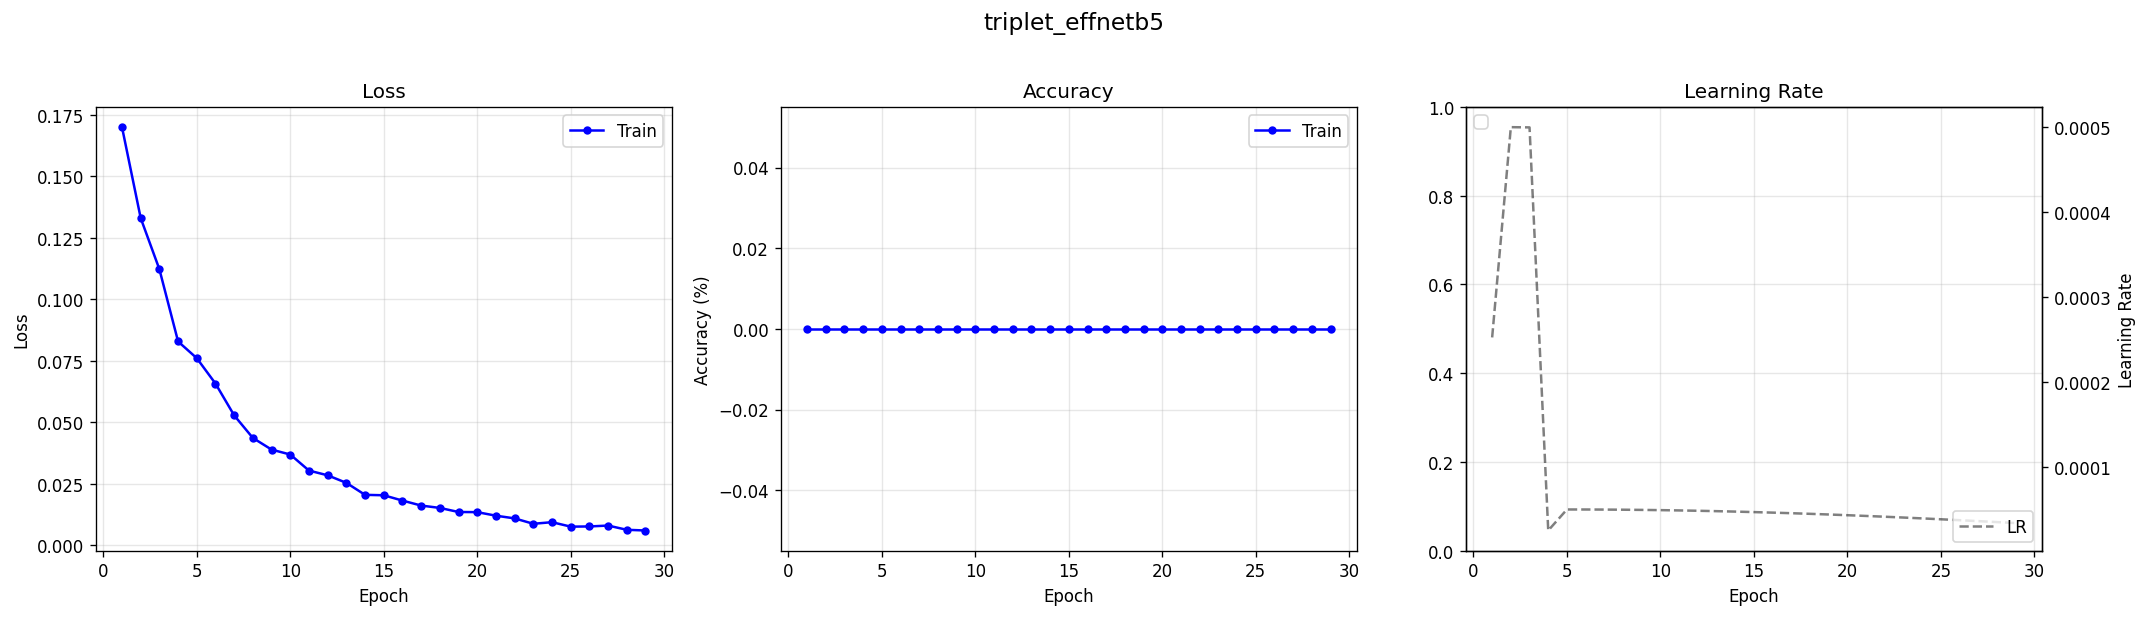

In [8]:
metrics_path = manager.root / "metrics.json"

with open(metrics_path, "r") as f:
    metrics = json.load(f)

plot_training_history(metrics, title=config.experiment_name)

In [10]:
print("\nFinal metrics (last epoch):")
for key in ["train_loss", "train_acc", "known_recall@1", 
            "known_recall@5", "mean_known_conf", "mean_new_whale_conf"]:
    if key in metrics:
        val = metrics[key][-1]
        if "acc" in key or "detection" in key or "recall" in key:
            print(f"  {key:<30s}: {val * 100:.2f}%")
        else:
            print(f"  {key:<30s}: {val:.4f}")



Final metrics (last epoch):
  train_loss                    : 0.0059
  train_acc                     : 0.00%
  known_recall@1                : 70.20%
  known_recall@5                : 79.80%
  mean_known_conf               : 0.9051
  mean_new_whale_conf           : 0.8852


### Embedding quality

In [7]:
eval_config, data = get_eval_config_and_data()

triplet_model = build_model(config, data["num_classes"], device)
manager.load_checkpoint(triplet_model, checkpoint="best")

train_loader, val_loader = build_retrieval_eval_loaders(eval_config, data)

print("Triplet retrieval performance:")
triplet_retrieval = evaluate_retrieval(
    triplet_model, train_loader, val_loader, eval_config, device,
)

plot_embedding_tsne(triplet_model, val_loader, data, device,
                    title="Triplet Loss Embedding — t-SNE", combine_loaders=[train_loader])

Split (seed=42): train=7452 (4250 cls), val=1217 (405 new_whale), test=1181 (405 new_whale)
[21:58:01] Loading checkpoint: experiments/20260527_195128_triplet_effnetb5_e7fa63cf/checkpoints/best.pth
[21:58:01] Resuming from epoch 23
Triplet retrieval performance:


NameError: name 'evaluate_retrieval' is not defined